In [1]:
import numpy as np
import pandas as pd
import cvxpy as cvx
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv("DailyReturns.csv", index_col='Date', parse_dates=True)
df.head()

,AAPL,AMZN,BRK-B,GOOG,LLY,META,MSFT,NVDA,TSM
Date,,,,,,,,,
2015-01-02,-0.514999,-0.203000,-2.330002,-0.209425,0.290001,-0.130005,0.099998,0.00000,-0.170000
2015-01-05,-0.510000,-0.241000,-1.809998,-0.468214,-0.360001,-0.790001,-0.039997,-0.00850,-0.400000
2015-01-06,-0.070000,-0.347501,-0.800003,-0.650215,-0.199997,-1.080002,-0.730000,-0.01575,0.040001
2015-01-07,0.137501,0.046000,0.940002,-0.294191,-0.799995,-0.610001,0.250000,-0.00475,0.080000
2015-01-08,0.664999,0.007000,0.769989,0.233858,0.870003,1.440002,0.840000,0.01250,0.119999


In [3]:
df.describe()

,AAPL,AMZN,BRK-B,GOOG,LLY,META,MSFT,NVDA,TSM
count,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000
mean,0.075099,-0.032573,-0.043595,0.055229,0.080576,0.119893,0.047421,0.004179,-0.032855
std,1.573958,1.791163,2.284660,1.247087,4.367827,3.896041,2.827448,0.842414,1.271779
min,-7.080002,-7.990494,-12.859985,-6.527496,-58.130005,-23.260010,-15.670013,-9.020004,-8.589996
25%,-0.403749,-0.707001,-1.139984,-0.399502,-0.950008,-1.465012,-0.820000,-0.077125,-0.400001
50%,0.049999,0.000000,-0.010010,0.044006,0.099998,0.090027,0.070004,0.002250,0.009998
75%,0.548752,0.674004,1.104996,0.570000,1.149998,1.774994,1.000000,0.095875,0.375004
max,13.500000,11.520508,15.200012,7.673492,31.679993,28.309967,22.079987,8.389999,14.089996


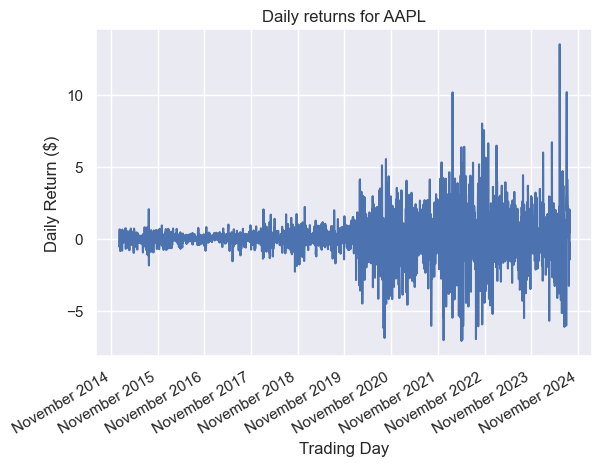

In [4]:
ticker = 'AAPL'
ax = sns.lineplot(y=ticker, x=df.index, data=df)
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B %Y"))  # e.g., "January 2026"
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.gcf().autofmt_xdate()
plt.ylabel("Daily Return ($)")
plt.xlabel("Trading Day")
plt.title(f"Daily returns for {ticker}")
plt.show()

In [5]:
Sigma = df.cov().to_numpy()
r = df.mean().to_numpy()
n = df.shape[1]

In [6]:
#Now, solve for an optimal portfolio via Markowitz

In [15]:
x=cvx.Variable(n, nonneg=True)
return_rate = cvx.Parameter()
obj=cvx.Minimize(0.5 * cvx.quad_form(x, Sigma, assume_PSD=True))
cons=[cvx.sum(x) == 1., r.T @ x >= 0.05]
prob = cvx.Problem(obj, cons)
prob.solve(verbose=True)

(CVXPY) Jul 23 02:49:39 PM: Your problem has 9 variables, 2 constraints, and 0 parameters.
(CVXPY) Jul 23 02:49:39 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 23 02:49:39 PM: DCP verification time: 0.0003 seconds.
(CVXPY) Jul 23 02:49:39 PM: Expression tree has 5 nodes.
(CVXPY) Jul 23 02:49:39 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 23 02:49:39 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 23 02:49:39 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 23 02:49:39 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Jul 23 02:49:39 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> GUROBI
(CVXPY) Jul 23 02:49:39 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 23 02:49:39 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 23 02:49:39 PM: Applyin

                                     CVXPY                                     
                                     v1.9.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
QCPDual  1

Optimize a 

(CVXPY) Jul 23 02:49:40 PM: Problem status: optimal
(CVXPY) Jul 23 02:49:40 PM: Optimal value: 5.469e-01
(CVXPY) Jul 23 02:49:40 PM: Compilation took 2.134e-02 seconds
(CVXPY) Jul 23 02:49:40 PM: Solver (including time spent in interface) took 4.643e-02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


np.float64(0.5469117583794724)

In [16]:
print(dict(zip(df.columns, x.value)))

{'AAPL': np.float64(0.31053418407225075), 'AMZN': np.float64(3.078660321908044e-09), 'BRK-B': np.float64(9.460165221455893e-10), 'GOOG': np.float64(0.4436789848542589), 'LLY': np.float64(0.015031735917448793), 'META': np.float64(6.32795877994378e-08), 'MSFT': np.float64(4.03753497334161e-09), 'NVDA': np.float64(0.2307592137419661), 'TSM': np.float64(0.0)}


In [21]:
x=cvx.Variable(n, nonneg=True)
return_rate=cvx.Parameter()
obj=cvx.Minimize(0.5 * cvx.quad_form(x, Sigma, assume_PSD=True))
cons=[cvx.sum(x) == 1., r.T @ x >= return_rate]
prob = cvx.Problem(obj, cons)

In [19]:
#%%timeit -n 1 -r 1
#time this block
rates = np.linspace(-.10, .2, 1000)
variances = np.empty(rates.size)
for i, rate in enumerate(rates):
    return_rate.value = rate
    prob.solve()
    if prob.status == 'optimal':
        variances[i] = prob.value
    else:
        variances[i] = np.inf    
#we are solving many optimization problems in this time!

SolverError: Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.

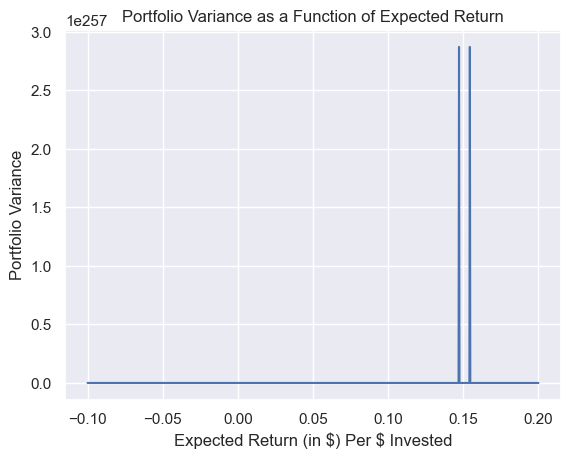

In [22]:
plt.plot(rates, variances)
plt.xlabel('Expected Return (in \\$) Per $ Invested')
plt.ylabel('Portfolio Variance')
plt.title("Portfolio Variance as a Function of Expected Return")
plt.show()
